# RetailIQ: AI-Powered Retail Sales Analytics

## Project by
Jenifer R

### Objective
To analyze retail sales data, generate business insights, build visualizations, create a Power BI dashboard, and develop a machine learning model for sales prediction.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Retailstores_Raw.xlsx to Retailstores_Raw.xlsx


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("Retailstores_Raw.xlsx")

In [ ]:
df.shape

(1000, 9)

In [ ]:
df.columns

Index(['Bill_ID', 'Date', 'Product_Name', 'Category', 'Brand', 'Quantity',
       'Selling_Price', 'Cost_Price', 'Payment_Mode'],
      dtype='object')

In [ ]:
df.head()

,Bill_ID,Date,Product_Name,Category,Brand,Quantity,Selling_Price,Cost_Price,Payment_Mode
0,B0001,14-02-2026,Rice,Grocery,Aashirvaad,11.0,60.0,50.0,cash
1,B0002,31-01-2026,Detergent,Household,Surf Excel,2.0,220.0,190.0,upi
2,B0003,11-06-2026,Chips,Snacks,Lays,8.0,20.0,12.0,upi
3,B0004,02-06-2026,Chips,Snacks,Lays,13.0,20.0,12.0,Cash
4,B0005,05-01-2026,Soap,Personal Care,Lux,10.0,40.0,30.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bill_ID        1000 non-null   object 
 1   Date           989 non-null    object 
 2   Product_Name   985 non-null    object 
 3   Category       991 non-null    object 
 4   Brand          919 non-null    object 
 5   Quantity       994 non-null    float64
 6   Selling_Price  989 non-null    float64
 7   Cost_Price     992 non-null    float64
 8   Payment_Mode   832 non-null    object 
dtypes: float64(3), object(6)
memory usage: 70.4+ KB


In [ ]:
df.isnull().sum()

,0
Bill_ID,0
Date,11
Product_Name,15
Category,9
Brand,81
Quantity,6
Selling_Price,11
Cost_Price,8
Payment_Mode,168


In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
df[df.duplicated()]

,Bill_ID,Date,Product_Name,Category,Brand,Quantity,Selling_Price,Cost_Price,Payment_Mode
990,B0202,09-04-2026,Chocolate,SNACKS,Cadbury,14.0,25.0,18.0,Card
991,B0322,17-03-2026,Rice,Grocery,Aashirvaad,2.0,60.0,50.0,Cash
992,B0312,15-06-2026,Milk,Dairy,Aavin,15.0,30.0,25.0,upi
993,B0436,16-02-2026,Biscuits,snacks,NaN,10.0,30.0,20.0,upi
994,B0519,09-03-2026,Biscuits,snacks,Britannia,13.0,30.0,20.0,NaN
995,B0635,22-01-2026,Rice,Grocery,Aashirvaad,2.0,60.0,50.0,NaN
996,B0725,13-02-2026,Detergent,Household,Surf Excel,12.0,220.0,190.0,UPI
997,B0369,07-05-2026,Detergent,Household,Surf Excel,3.0,220.0,190.0,cash
998,B0871,24-01-2026,Chocolate,SNACKS,Cadbury,2.0,25.0,18.0,Cash
999,B0840,09-05-2026,Biscuits,snacks,Britannia,7.0,30.0,20.0,upi


In [ ]:
before_rows = df.shape[0]

df = df.drop_duplicates()

after_rows = df.shape[0]

removed_duplicates = before_rows - after_rows

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Exact duplicate records removed:", removed_duplicates)

Rows before removing duplicates: 1000
Rows after removing duplicates: 990
Exact duplicate records removed: 10


In [ ]:
display(df)

,Bill_ID,Date,Product_Name,Category,Brand,Quantity,Selling_Price,Cost_Price,Payment_Mode
0,B0001,14-02-2026,Rice,Grocery,Aashirvaad,11.0,60.0,50.0,cash
1,B0002,31-01-2026,Detergent,Household,Surf Excel,2.0,220.0,190.0,upi
2,B0003,11-06-2026,Chips,Snacks,Lays,8.0,20.0,12.0,upi
3,B0004,02-06-2026,Chips,Snacks,Lays,13.0,20.0,12.0,Cash
4,B0005,05-01-2026,Soap,Personal Care,Lux,10.0,40.0,30.0,NaN
...,...,...,...,...,...,...,...,...,...
985,B0986,31-01-2026,Chocolate,NaN,Cadbury,10.0,25.0,18.0,NaN
986,B0987,29-03-2026,Tea Powder,Beverages,Tata Tea,4.0,180.0,150.0,Cash
987,B0988,16-04-2026,Milk,Dairy,Aavin,10.0,30.0,25.0,cash
988,B0989,12-03-2026,Tea Powder,Beverages,Tata Tea,6.0,180.0,150.0,upi


In [ ]:
df["Brand"] = df["Brand"].fillna("Unknown")

In [ ]:
df["Payment_Mode"] = df["Payment_Mode"].fillna("Cash")

In [ ]:
df["Category"] = df["Category"].str.strip().str.title()

In [ ]:
df["Payment_Mode"] = df["Payment_Mode"].str.upper()

In [ ]:
display(df)

,Bill_ID,Date,Product_Name,Category,Brand,Quantity,Selling_Price,Cost_Price,Payment_Mode
0,B0001,14-02-2026,Rice,Grocery,Aashirvaad,11.0,60.0,50.0,CASH
1,B0002,31-01-2026,Detergent,Household,Surf Excel,2.0,220.0,190.0,UPI
2,B0003,11-06-2026,Chips,Snacks,Lays,8.0,20.0,12.0,UPI
3,B0004,02-06-2026,Chips,Snacks,Lays,13.0,20.0,12.0,CASH
4,B0005,05-01-2026,Soap,Personal Care,Lux,10.0,40.0,30.0,CASH
...,...,...,...,...,...,...,...,...,...
985,B0986,31-01-2026,Chocolate,NaN,Cadbury,10.0,25.0,18.0,CASH
986,B0987,29-03-2026,Tea Powder,Beverages,Tata Tea,4.0,180.0,150.0,CASH
987,B0988,16-04-2026,Milk,Dairy,Aavin,10.0,30.0,25.0,CASH
988,B0989,12-03-2026,Tea Powder,Beverages,Tata Tea,6.0,180.0,150.0,UPI


In [ ]:
df["Revenue"] = df["Quantity"] * df["Selling_Price"]

In [ ]:
df["Profit"] = df["Revenue"] - (
    df["Quantity"] * df["Cost_Price"]
)

In [ ]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

In [ ]:
df["Month"] = df["Date"].dt.month_name()

In [ ]:
df["Day"] = df["Date"].dt.day_name()

In [ ]:
display(df)

,Bill_ID,Date,Product_Name,Category,Brand,Quantity,Selling_Price,Cost_Price,Payment_Mode,Revenue,Profit,Month,Day
0,B0001,2026-02-14,Rice,Grocery,Aashirvaad,11.0,60.0,50.0,CASH,660.0,110.0,February,Saturday
1,B0002,2026-01-31,Detergent,Household,Surf Excel,2.0,220.0,190.0,UPI,440.0,60.0,January,Saturday
2,B0003,2026-06-11,Chips,Snacks,Lays,8.0,20.0,12.0,UPI,160.0,64.0,June,Thursday
3,B0004,2026-06-02,Chips,Snacks,Lays,13.0,20.0,12.0,CASH,260.0,104.0,June,Tuesday
4,B0005,2026-01-05,Soap,Personal Care,Lux,10.0,40.0,30.0,CASH,400.0,100.0,January,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,B0986,2026-01-31,Chocolate,NaN,Cadbury,10.0,25.0,18.0,CASH,250.0,70.0,January,Saturday
986,B0987,2026-03-29,Tea Powder,Beverages,Tata Tea,4.0,180.0,150.0,CASH,720.0,120.0,March,Sunday
987,B0988,2026-04-16,Milk,Dairy,Aavin,10.0,30.0,25.0,CASH,300.0,50.0,April,Thursday
988,B0989,2026-03-12,Tea Powder,Beverages,Tata Tea,6.0,180.0,150.0,UPI,1080.0,180.0,March,Thursday


In [ ]:
df["Revenue"].sum()

np.float64(657110.0)

In [ ]:
df["Profit"].sum()

np.float64(111759.0)

In [ ]:
df.groupby("Product_Name")["Quantity"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

,Quantity
Product_Name,
Tea Powder,784.0
Detergent,750.0
Chips,696.0
Biscuits,687.0
Milk,667.0
Rice,629.0
Chocolate,623.0
Oil,618.0
Sugar,616.0


In [ ]:
df.groupby("Category")["Revenue"].sum()

,Revenue
Category,
Beverages,161460.0
Dairy,22680.0
Grocery,188625.0
Household,193820.0
Personal Care,27360.0
Snacks,56785.0


In [ ]:
df.to_excel(
    "Retailstores_Cleaned.xlsx",
    index=False
)

In [ ]:
from google.colab import files
files.download("Retailstores_Cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Retailstores_Cleaned.xlsx to Retailstores_Cleaned (1).xlsx


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("Retailstores_Cleaned.xlsx")

In [ ]:
df.isnull().sum()

,0
Bill_ID,0
Date,11
Product_Name,15
Category,9
Brand,0
Quantity,6
Selling_Price,11
Cost_Price,8
Payment_Mode,0
Revenue,17


In [ ]:
df["Date"] = df["Date"].fillna(method="ffill")

/tmp/ipykernel_7629/195213061.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Date"] = df["Date"].fillna(method="ffill")


In [ ]:
df["Product_Name"] = df["Product_Name"].fillna("Unknown Product")

In [ ]:
df["Category"] = df["Category"].fillna("Unknown")

In [ ]:
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

In [ ]:
df["Selling_Price"] = df["Selling_Price"].fillna(
    df["Selling_Price"].median()
)

In [ ]:
df["Cost_Price"] = df["Cost_Price"].fillna(
    df["Cost_Price"].median()
)

In [ ]:
df.isnull().sum()

,0
Bill_ID,0
Date,0
Product_Name,0
Category,0
Brand,0
Quantity,0
Selling_Price,0
Cost_Price,0
Payment_Mode,0
Revenue,17


In [ ]:
df["Revenue"] = df["Quantity"] * df["Selling_Price"]

df["Profit"] = (
    df["Revenue"]
    - (df["Quantity"] * df["Cost_Price"])
)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

df["Month"] = df["Date"].dt.month_name()

df["Day"] = df["Date"].dt.day_name()

In [ ]:
df.isnull().sum()

,0
Bill_ID,0
Date,0
Product_Name,0
Category,0
Brand,0
Quantity,0
Selling_Price,0
Cost_Price,0
Payment_Mode,0
Revenue,0


In [ ]:
df.to_excel(
    "Retailstores_Cleaned.xlsx",
    index=False
)

In [ ]:
from google.colab import files
files.download("Retailstores_Cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.shape

(990, 13)

In [ ]:
df.columns

Index(['Bill_ID', 'Date', 'Product_Name', 'Category', 'Brand', 'Quantity',
       'Selling_Price', 'Cost_Price', 'Payment_Mode', 'Revenue', 'Profit',
       'Month', 'Day'],
      dtype='object')

In [ ]:
# EXPLORATORY DATA ANALYSIS
total_revenue = df["Revenue"].sum()
print("Total Revenue =", total_revenue)

Total Revenue = 663390.0


In [ ]:
total_profit = df["Profit"].sum()
print("Total Profit =", total_profit)

Total Profit = 112007.0


In [ ]:
total_quantity = df["Quantity"].sum()
print("Total Quantity Sold =", total_quantity)

Total Quantity Sold = 7875.0


In [ ]:
total_transactions = df["Bill_ID"].nunique()
print("Total Transactions =", total_transactions)

Total Transactions = 990


In [ ]:
top_products = (
    df.groupby("Product_Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(top_products.head(10))

Product_Name
Tea Powder    784.0
Detergent     750.0
Chips         712.0
Biscuits      695.0
Milk          667.0
Rice          629.0
Oil           626.0
Sugar         624.0
Chocolate     623.0
Soap          575.0
Name: Quantity, dtype: float64


In [ ]:
category_sales = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Household        194900.0
Grocery          192025.0
Beverages        161620.0
Snacks            58145.0
Personal Care     27400.0
Dairy             22920.0
Unknown            6380.0
Name: Revenue, dtype: float64


In [ ]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

Category
Grocery          30340.0
Beverages        27415.0
Household        22815.0
Snacks           19867.0
Personal Care     6700.0
Dairy             3780.0
Unknown           1090.0
Name: Profit, dtype: float64


In [ ]:
payment_analysis = df["Payment_Mode"].value_counts()
print(payment_analysis)

Payment_Mode
CASH    494
UPI     330
CARD    166
Name: count, dtype: int64


In [ ]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

print(monthly_sales)

Month
April        90010.0
February    101020.0
January     108490.0
June        116225.0
March       109915.0
May         137730.0
Name: Revenue, dtype: float64


In [ ]:
day_sales = (
    df.groupby("Day")["Revenue"]
      .sum()
)

print(day_sales)

Day
Friday       122675.0
Monday        88905.0
Saturday      78350.0
Sunday        83360.0
Thursday      96640.0
Tuesday      112410.0
Wednesday     81050.0
Name: Revenue, dtype: float64


In [ ]:
top_profit = (
    df.groupby("Product_Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(top_profit.head(10))

Product_Name
Tea Powder     23905.0
Detergent      20235.0
Oil            14475.0
Biscuits        6950.0
Sugar           6135.0
Chips           5896.0
Rice            5770.0
Soap            5645.0
Chocolate       4511.0
Tea Powder      3690.0
Name: Profit, dtype: float64


In [ ]:
df.to_excel(
    "Retailstores_Analytical_Dataset.xlsx",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "Retailstores_Analytical_Dataset.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# BUSINESS INSIGHTS FROM EDA

## Insight 1: Total Revenue
The retail store generated a total revenue of ₹663,390 during the six-month analysis period, indicating consistent sales performance and customer demand.

## Insight 2: Total Profit
The business earned a total profit of ₹112,007, demonstrating healthy profitability and effective pricing strategies.

## Insight 3: Total Quantity Sold
A total of 7,875 products were sold across 990 transactions, showing strong customer purchasing activity.

## Insight 4: Highest Revenue-Generating Category
The Household category generated the highest revenue of ₹194,900, making it the primary contributor to overall business sales.

## Insight 5: Most Profitable Category
The Grocery category generated the highest profit of ₹30,340, indicating that it provides the best profit margins for the business.

## Insight 6: Best-Selling Product
Tea Powder was the best-selling product with a total quantity sold of 784 units, highlighting its high customer demand.

## Insight 7: Most Profitable Product
Tea Powder was also the most profitable product, contributing a total profit of ₹23,905.

## Insight 8: Customer Payment Preference
Cash was the most preferred payment mode with 494 transactions, followed by UPI with 330 transactions, indicating that customers still prefer cash payments despite increasing digital adoption.

## Insight 9: Highest Sales Month
May recorded the highest revenue of ₹137,730, suggesting seasonal demand or increased customer purchases during this period.

## Insight 10: Highest Revenue Day
Friday generated the highest revenue of ₹122,675, indicating peak customer shopping activity before weekends.

## Insight 11: Business Performance Observation
Household and Grocery categories together contributed a major portion of the total revenue and profit, making them the most important business segments.

## Insight 12: Strategic Recommendation
The business should increase inventory levels for high-performing products such as Tea Powder, Detergent, and Rice while focusing promotional activities on Grocery and Household categories to maximize future revenue and profit.

# Conclusion

The retail sales dataset was successfully cleaned and analyzed using Python and Pandas. Business insights were generated from Exploratory Data Analysis (EDA), identifying key trends in revenue, profit, product sales, and customer purchasing behavior.

Next Steps:
- Data Visualization using Matplotlib
- Power BI Dashboard
- Machine Learning Model
- GitHub Integration
- Pipeline Automation


In [ ]:
import matplotlib.pyplot as plt

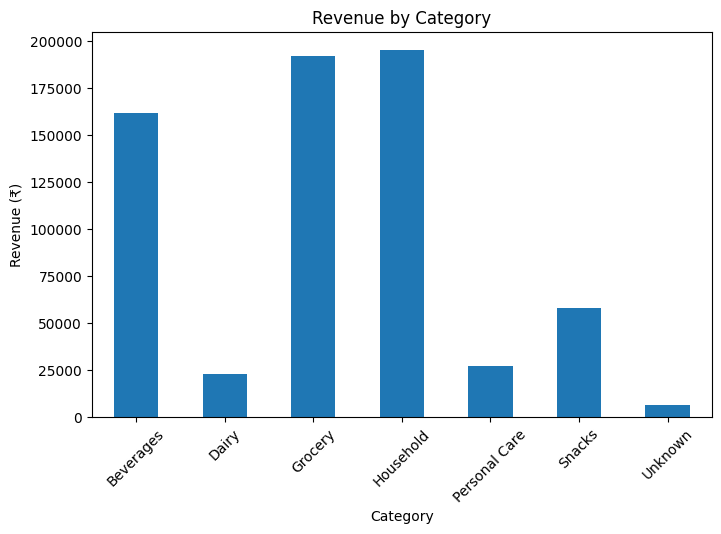

In [ ]:
category_revenue = df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

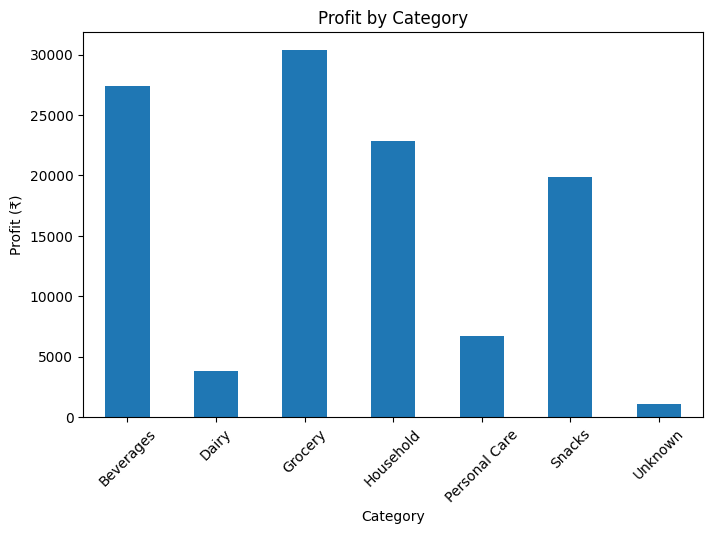

In [ ]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")

plt.xticks(rotation=45)

plt.show()

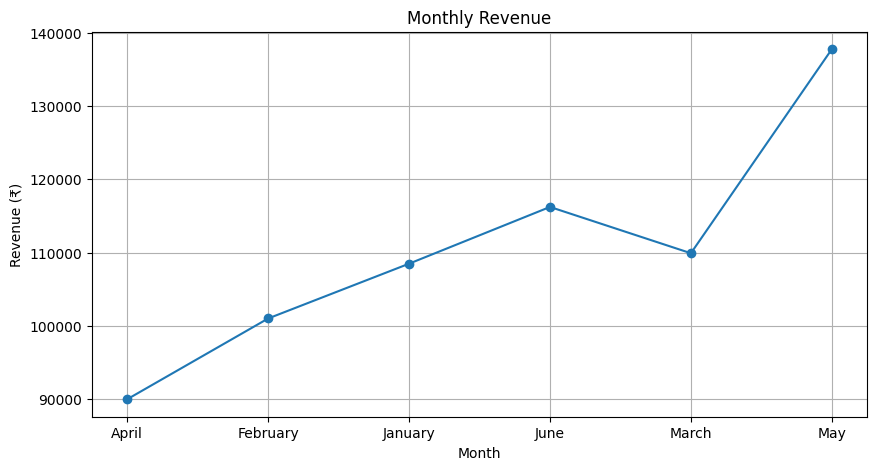

In [ ]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.grid(True)

plt.show()

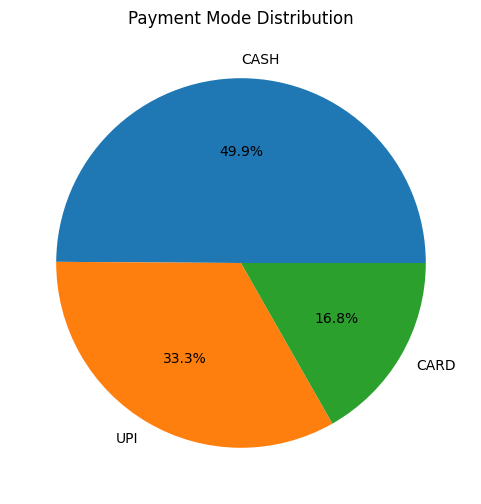

In [ ]:
payment = df["Payment_Mode"].value_counts()

plt.figure(figsize=(6,6))
payment.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Mode Distribution")
plt.ylabel("")

plt.show()

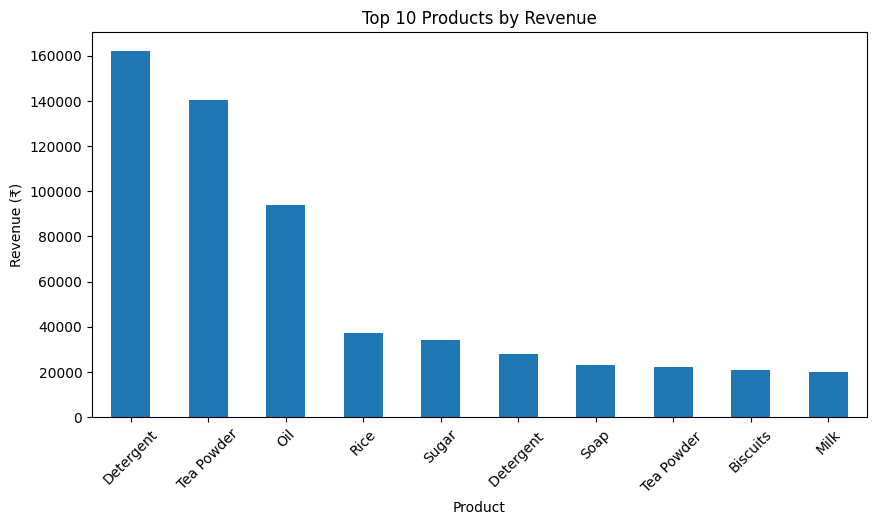

In [ ]:
top_products = (
    df.groupby("Product_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

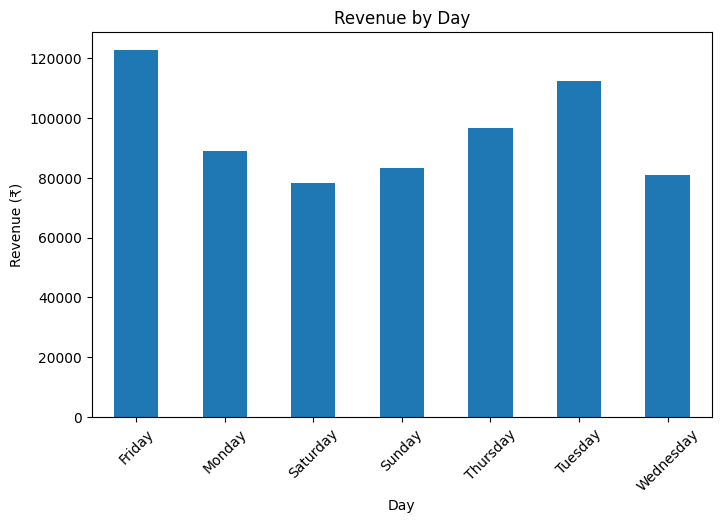

In [ ]:
day_revenue = df.groupby("Day")["Revenue"].sum()

plt.figure(figsize=(8,5))
day_revenue.plot(kind="bar")

plt.title("Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.show()

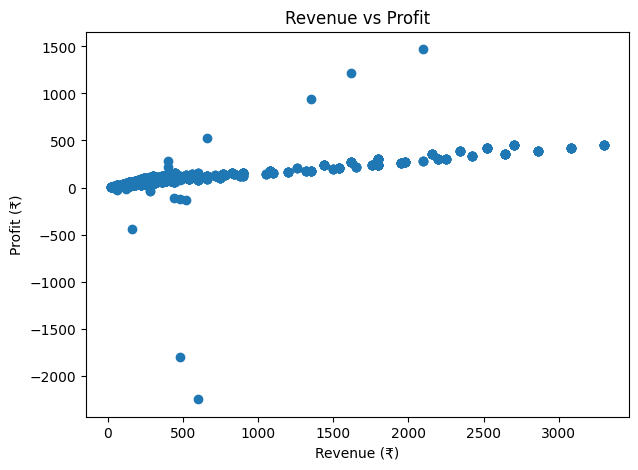

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["Revenue"], df["Profit"])

plt.title("Revenue vs Profit")
plt.xlabel("Revenue (₹)")
plt.ylabel("Profit (₹)")

plt.show()